## Dataset Import

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\miche\.cache\kagglehub\datasets\mohamedamineferrag\edgeiiotset-cyber-security-dataset-of-iot-iiot\versions\5


In [2]:
import pandas as pd
df = pd.read_csv(path+'/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv')

C:\Users\miche\AppData\Local\Temp\ipykernel_19988\704471606.py:2: DtypeWarning: Columns (0: arp.dst.proto_ipv4, 1: arp.src.proto_ipv4, 2: http.file_data, 3: http.request.uri.query, 4: http.request.method, 5: http.referer, 6: http.request.full_uri, 7: http.request.version, 8: tcp.options, 9: tcp.payload, 10: tcp.srcport, 11: dns.qry.name.len, 12: mqtt.conack.flags, 13: mqtt.msg, 14: mqtt.protoname, 15: mqtt.topic) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+'/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv')


## Dataset Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  str    
 1   ip.src_host                157800 non-null  str    
 2   ip.dst_host                157800 non-null  str    
 3   arp.dst.proto_ipv4         157800 non-null  object 
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  object 
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   icmp.transmit_timestamp    157800 non-null  float64
 10  icmp.unused                157800 non-null  float64
 11  http.file_data             157800 non-null  object 
 12  http.content_length        157800 non-null  float64
 13  http.request.uri.query     157800 non-nu

In [4]:
df.head()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [5]:
X_cleaned = df.drop(['Attack_type', 'Attack_label'], axis=1)
y_cleaned = df['Attack_type']

In [6]:
from sklearn.model_selection import train_test_split

# Split train / test 
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (126240, 61)
Test: (31560, 61)


In [7]:
unique_counts = X_train.nunique().sort_values()


In [8]:
constant_features = unique_counts[unique_counts == 1].index

X_train_cleaned = X_train.drop(columns=constant_features)
X_test_cleaned = X_test.drop(columns=constant_features)

print("X_train:", X_train.shape)
print("X_train:", X_train_cleaned.shape)

X_train: (126240, 61)
X_train: (126240, 53)


In [9]:
X_train_cleaned.describe()

,arp.opcode,arp.hw.size,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,http.content_length,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,...,dns.retransmission,dns.retransmit_request,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver
count,126240.000000,126240.000000,126240.000000,126240.000000,1.262400e+05,126240.000000,126240.000000,1.262400e+05,1.262400e+05,126240.00000,...,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000,126240.000000
mean,0.014219,0.060219,3045.196760,3241.685290,3.961211e+04,14.812682,0.045524,7.192886e+07,1.358745e+09,25797.34512,...,0.001568,0.000008,0.007826,0.015653,2.529404,0.420081,0.158088,0.031305,0.190684,0.031305
std,0.149606,0.598071,11151.709307,11411.802267,1.745266e+06,252.542146,0.208452,3.110933e+08,1.295688e+09,21517.81472,...,0.196325,0.002815,0.088120,0.176240,20.419215,3.614950,1.276201,0.352481,2.130751,0.352481
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,2952.75000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1.000000e+00,1.162044e+09,23919.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,4.790000e+02,2.372228e+09,44720.25000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,6.000000,65532.000000,65524.000000,7.728902e+07,83655.000000,1.000000,2.147251e+09,4.294727e+09,65535.00000,...,28.000000,1.000000,1.000000,2.000000,224.000000,39.000000,14.000000,4.000000,24.000000,4.000000


## PCA e dataset misti

La PCA è progettata per feature numeriche e assume distanze geometriche significative tra i valori.

Per questo motivo, applicare PCA direttamente a feature categoriche non va bene.
Necessario codificare le label categoriche (one-hot encoding)
Codificare con label encoding non è generalmente appropriato, poiché il label encoding introduce relazioni numeriche artificiali tra le categorie.

Nella pratica, la PCA viene spesso applicata solo alle feature numeriche continue.

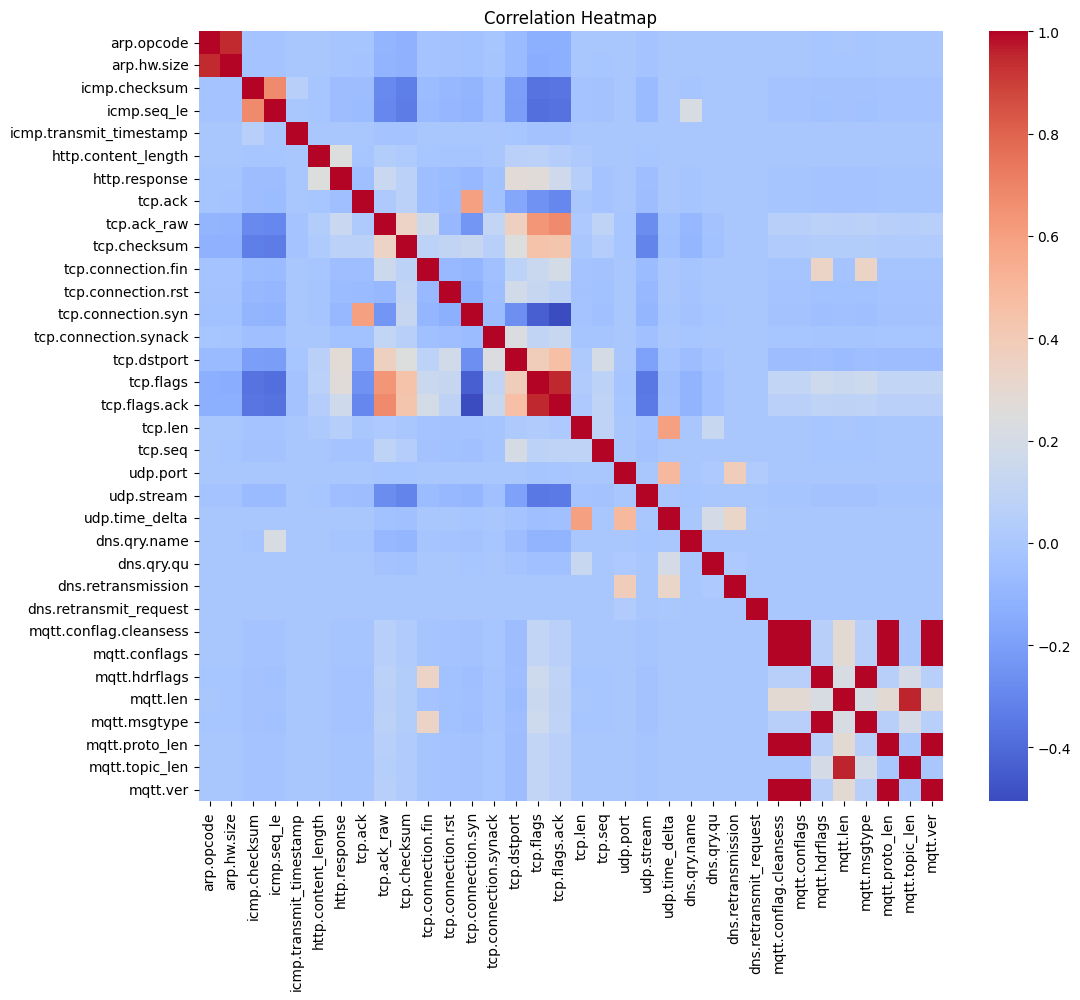

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

X_num = X_train_cleaned.select_dtypes(include=["int64", "float64"])
X_test_num = X_test_cleaned.select_dtypes(include=["int64", "float64"])


plt.figure(figsize=(12, 10))
sns.heatmap(X_num.corr(), cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

In [11]:
import numpy as np

corr_matrix = X_num.corr().abs()

# prendiamo solo la parte superiore (evita duplicati)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# soglia
threshold = 1 #decidiamo la soglia di ridondanza tra features

# colonne da eliminare
to_drop = [column for column in upper.columns if any(upper[column] >= threshold)]

print("Feature rimosse per alta correlazione:")
print(to_drop)

# Applichiamo la selezione
X_train_reduced = X_num.drop(columns=to_drop)
X_test_reduced = X_test_num.drop(columns=to_drop)

print("Originale:")
print("X_train:", X_train_cleaned.shape)

print("\nDataset con solo feature numeriche:")
print("X_train:", X_num.shape)

print("\nDopo rimozione feature non numeriche e correlate:")
print("X_train_reduced:", X_train_reduced.shape)

Feature rimosse per alta correlazione:
['mqtt.conflags', 'mqtt.msgtype', 'mqtt.proto_len', 'mqtt.ver']
Originale:
X_train: (126240, 53)

Dataset con solo feature numeriche:
X_train: (126240, 34)

Dopo rimozione feature non numeriche e correlate:
X_train_reduced: (126240, 30)


In [13]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Encoding del target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.squeeze())

# Correlazione feature-target
correlations = []

for col in X_train_reduced.columns:
    corr = np.corrcoef(
        X_train_reduced[col],
        y_train_encoded
    )[0, 1]
    
    correlations.append(abs(corr))

# Feature dopo variance threshold
X = X_train_reduced.copy()

mi_scores = mutual_info_classif(X, y_train_encoded, random_state=42)

# DataFrame comparativo
comparison_df = pd.DataFrame({
    "Feature": X_train_reduced.columns,
    "Abs Correlation": correlations,
    "Mutual Information": mi_scores
})

comparison_df = comparison_df.sort_values(
    "Mutual Information",
    ascending=False
)

print(comparison_df)

                    Feature  Abs Correlation  Mutual Information
14              tcp.dstport         0.161238            1.414523
7                   tcp.ack         0.076436            1.325492
18                  tcp.seq         0.001486            1.026277
8               tcp.ack_raw         0.257331            1.025243
15                tcp.flags         0.347135            0.806317
17                  tcp.len         0.014588            0.677407
9              tcp.checksum         0.243479            0.446308
20               udp.stream         0.176771            0.307765
2             icmp.checksum         0.305643            0.305945
16            tcp.flags.ack         0.354729            0.304455
3               icmp.seq_le         0.313597            0.298143
5       http.content_length         0.060347            0.181064
12       tcp.connection.syn         0.054244            0.110708
11       tcp.connection.rst         0.014711            0.090707
6             http.respon

Feature con:

- bassa correlazione feature-target,
- bassa Mutual Information feature-target,

sembrano contribuire poco alla previsione del target e possono essere candidate alla rimozione prima della PCA.

In [1]:
# Soglie
mi_threshold = 0.01
corr_threshold = 0.05

# Manteniamo le feature che NON sono basse in entrambe
selected_features = comparison_df[
    ~(
        (comparison_df["Mutual Information"] < mi_threshold) &
        (comparison_df["Abs Correlation"] < corr_threshold)
    )
]["Feature"]

removed_features = comparison_df[
    (
        (comparison_df["Mutual Information"] < mi_threshold) &
        (comparison_df["Abs Correlation"] < corr_threshold)
    )
]["Feature"]

print("Feature rimosse:")
print(removed_features.tolist())

print("Feature mantenute:")
print(selected_features.tolist())

# Dataset ridotto
X_train_selected = X_train_reduced[selected_features]

X_test_selected = X_test_reduced[selected_features]

print("Shape originale:", X_train_reduced.shape)
print("Shape ridotta:", X_train_selected.shape)

NameError: name 'comparison_df' is not defined

In [15]:
from sklearn.preprocessing import StandardScaler

# Scaling the features
scaler_cleaned = StandardScaler()
X_train_scaled = scaler_cleaned.fit_transform(X_train_selected)
X_test_scaled = scaler_cleaned.transform(X_test_selected)

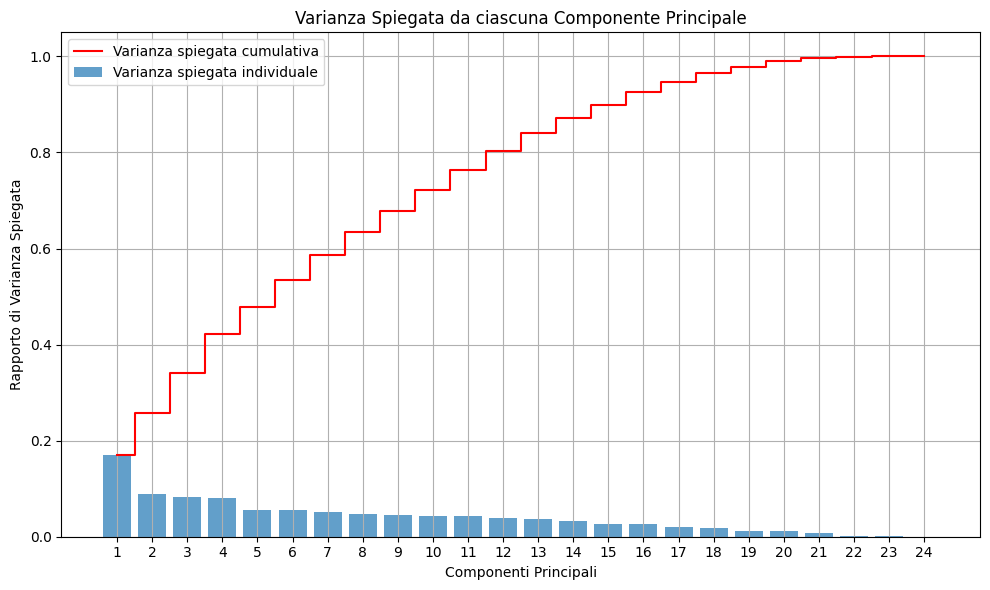

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA su tutti i dati di training scalati
pca_full = PCA()
pca_full.fit(X_train_scaled)

n_components = X_train_scaled.shape[1]

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_components + 1), pca_full.explained_variance_ratio_, alpha=0.7, align='center',
        label='Varianza spiegata individuale')
plt.step(range(1, n_components + 1), np.cumsum(pca_full.explained_variance_ratio_), where='mid',
         label='Varianza spiegata cumulativa', color='red')
plt.xlabel('Componenti Principali')
plt.ylabel('Rapporto di Varianza Spiegata')
plt.title('Varianza Spiegata da ciascuna Componente Principale')
plt.legend(loc='best')
plt.grid(True)
plt.xticks(range(1, n_components + 1))
plt.tight_layout()
plt.show()

## Interpretazione della varianza spiegata

La varianza spiegata è distribuita su molte componenti principali e non esiste un forte decadimento iniziale.

Questo suggerisce che:

- il dataset non è facilmente comprimibile in poche dimensioni lineari,
- l'informazione è distribuita su molte direzioni,
- non esiste una singola struttura lineare dominante.

Per mantenere il 95% della varianza sono necessarie molte componenti principali.

In [17]:
n_components_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1

print(f"Numero di componenti per il 95% della varianza: {n_components_95}")

# PCA finale
pca = PCA(n_components=n_components_95)

# Fit sul training set
pca.fit(X_train_scaled)

# Trasformazione train/test
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape originale:", X_train_scaled.shape)
print("Shape ridotta:", X_train_pca.shape)

Numero di componenti per il 95% della varianza: 18
Shape originale: (126240, 24)
Shape ridotta: (126240, 18)


In [18]:
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt

# LLE sullo stesso dataset scalato usato per PCA
# LLE può essere numericamente sensibile.
# In questo caso utilizziamo eigen_solver='dense' per evitare problemi numerici di ARPACK dovuti a matrici singolari o mal condizionate.
lle = LocallyLinearEmbedding(
    n_neighbors=10, n_components=2, method='standard', eigen_solver="dense")

X_lle = lle.fit_transform(X_train_scaled)

# Visualizzazione
plt.figure(figsize=(7, 6))

plt.scatter(
    X_lle[:, 0],
    X_lle[:, 1],
    c=y_train,
    cmap='viridis',
    s=15
)

plt.title("LLE Projection")
plt.xlabel("LLE1")
plt.ylabel("LLE2")
plt.grid(True)

plt.show()

MemoryError: Unable to allocate 119. GiB for an array with shape (126240, 126240) and data type float64

## Limiti pratici di LLE

A differenza della PCA, LLE può diventare molto costoso su dataset grandi.

Nel nostro caso, il numero elevato di campioni rende difficile applicare LLE all'intero training set a causa dei requisiti computazionali e di memoria.

Questo evidenzia una differenza pratica importante:

- PCA scala bene anche su dataset molto grandi,
- le tecniche di manifold learning possono diventare rapidamente costose e numericamente instabili.

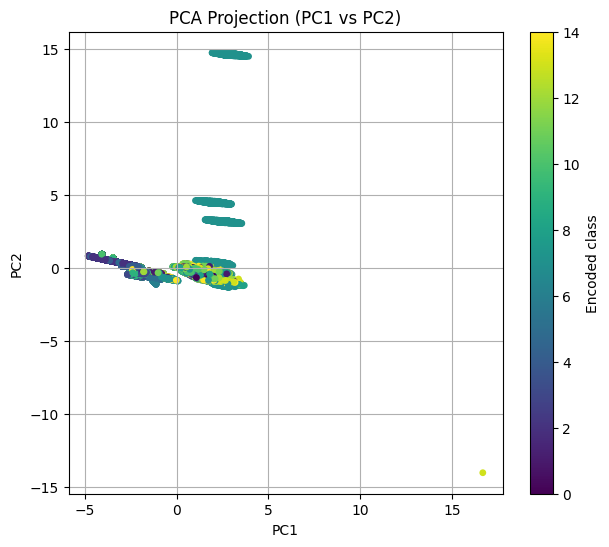

Varianza spiegata da PC1: 0.171
Varianza spiegata da PC2: 0.088
Varianza cumulativa: 0.258


In [19]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pca_due = PCA(n_components=2)

# Fit sul training set
pca_due.fit(X_train_scaled)

# Trasformazione train/test
X_train_pca_due = pca_due.transform(X_train_scaled)
X_test_pca_due = pca_due.transform(X_test_scaled)

# Encoding delle classi per la colorazione
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train.squeeze())

plt.figure(figsize=(7, 6))

plt.scatter(
    X_train_pca_due[:, 0],
    X_train_pca_due[:, 1],
    c=y_encoded,
    cmap='viridis',
    s=15
)

plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.colorbar(label="Encoded class")

plt.show()

print(f"Varianza spiegata da PC1: {pca_due.explained_variance_ratio_[0]:.3f}")
print(f"Varianza spiegata da PC2: {pca_due.explained_variance_ratio_[1]:.3f}")
print(f"Varianza cumulativa: {pca_due.explained_variance_ratio_.sum():.3f}")

## Possibili considerazioni sul dataset

Dalla PCA osserviamo che:

- la varianza è distribuita su molte componenti,
- non esiste una forte separazione lineare globale,
- le classi mostrano overlap significativo nel piano PC1-PC2.

Questo suggerisce che modelli lineari semplici potrebbero non essere sufficienti, ma non si evince una struttura non lineare chiara.

Poiché (ultima slide da "supervised learning"):

- il dataset è grande,
- non abbiamo particolari requisiti di interpretabilità,
- la struttura del problema non è chiaramente nota,

un possibile approccio iniziale può essere l'utilizzo di modelli basati sulla distanza, come k-NN.

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import time

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean"]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=1
)

start = time.time()

grid_search.fit(X_train_pca, y_train.squeeze())

end = time.time()

print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior F1 macro CV: {grid_search.best_score_:.4f}")
print(f"Tempo: {end - start:.2f} secondi")

Migliori parametri: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Miglior F1 macro CV: 0.7180
Tempo: 121.99 secondi


##### Nota: in una pipeline completamente rigorosa, scaling e PCA andrebbero inseriti dentro la cross-validation. Qui sono applicati prima per rendere il flusso più leggibile.

Migliori parametri:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}

Miglior F1 macro CV: 0.7180

Accuracy sul test set: 0.7769

Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.95      0.94      0.94      2039
            DDoS_HTTP       0.55      0.56      0.55      2112
            DDoS_ICMP       1.00      0.99      0.99      2818
             DDoS_TCP       0.90      0.87      0.89      2050
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.84      0.64      0.73       200
                 MITM       0.40      1.00      0.57       243
               Normal       0.87      0.89      0.88      4860
             Password       0.36      0.24      0.29      1998
        Port_Scanning       0.85      0.93      0.89      2014
           Ransomware       0.92      0.85      0.88      2185
        SQL_injection       0.53      0.58      0.55      2062
           

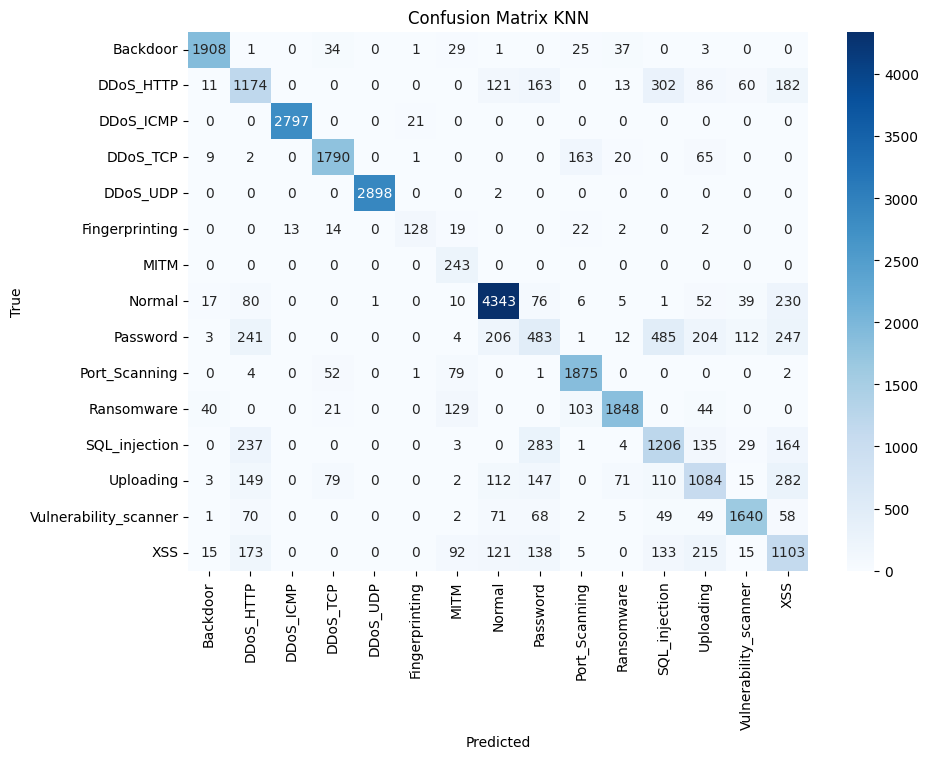

Accuracy KNN: 0.7769328263624842


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Migliori parametri trovati
print("Migliori parametri:")
print(grid_search.best_params_)

print(f"\nMiglior F1 macro CV: {grid_search.best_score_:.4f}")

# Miglior modello
best_model = grid_search.best_estimator_

# Predizioni sul test set
y_pred = best_model.predict(X_test_pca)

# Accuracy
accuracy = best_model.score(X_test_pca, y_test.squeeze())

print(f"\nAccuracy sul test set: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test.squeeze(), y_pred))

labels = np.unique(y_test)

cm_knn = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix KNN')
plt.show()
#Accuratezza
from sklearn.metrics import accuracy_score
accuracy_knn = accuracy_score(y_test, y_pred)
print("Accuracy KNN:", accuracy_knn)
